# **머신러닝 모델링(퀴즈)**

+ 이번시간에는 머신러닝 프로세스를 따라서 실습해 보겠습니다.
+ 즉, 데이터 파일 읽기, EDA 데이터 분석, 데이터 전처리, Train, Test 데이터셋 분할, 정규화, 모델 생성 및 학습 순으로 진행하겠습니다.
+ 아래와 같은 여러가지 머신러닝 모델에 대해서 살펴 보고 어떤 모델이 성능이 더 좋은지도 같이 보도록 하겠습니다.
     + 단일 분류예측 모델 : LogisticRegression, KNN, DecisionTree
     + 앙상블(Ensemble) 모델 : RandomForest, XGBoost
+ 솔직히, 머신러닝이 딥러닝보다 코딩하기 쉽습니다. 4줄 템플릿에 맞쳐 코딩하면 되기 때문입니다.
+ 한가지 당부 드리고 싶은 말은 "백문이불여일타" 입니다. 
+ 이론보다 실습이 더 많은 시간과 노력이 투자 되어야 합니다.

### **학습목차**
- 머신러닝 모델 프로세스
     - 데이터 가져오기
     - 데이터 전처리
     - Train, Test 데이터셋 분할
     - 데이터 정규화
     - 단일 분류예측 모델 : LogisticRegression, KNN, DecisionTree
     - 앙상블(Ensemble) 모델 : RandomForest, XGBoost, LGBM, Stacking, Weighted Blending


# 
## **1. 실습을 위한 셋팅 설정**

In [1]:
# 코드실행시 경고 메시지 무시

import warnings
warnings.filterwarnings(action='ignore') 

#
## **2. 머신러닝 모델 프로세스**
① 라이브러리 임포트(import)  
② 데이터 가져오기(Loading the data)  
③ 탐색적 데이터 분석(Exploratory Data Analysis)  
④ 데이터 전처리(Data PreProcessing) : 데이터타입 변환, Null 데이터 처리, 누락데이터 처리, 
더미특성 생성, 특성 추출 (feature engineering) 등  
⑤ Train, Test  데이터셋 분할  
⑥ 데이터 정규화(Normalizing the Data)  
⑦ 모델 개발(Creating the Model)  
⑧ 모델 성능 평가

####
### **① 라이브러리 임포트**

##### 필요 라이브러리 임포트

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

####
### **② 데이터 로드**

#### cust_data1.csv 파일 컬럼명
+ 고객등급(class), 성별(sex), 나이(age), 사용서비스수(service), 서비스중지여부 (stop), 미납여부(npay)
+ 3개월 평균 요금(avg_bill), A서비스 3개월 평균요금(A_bill), B서비스 3개월 평균요금(B_bill), 해지여부(termination)

In [4]:
# 앞쪽 전처리에서 저장한 cust_data1.csv 파일 읽기
df = pd.read_csv('cust_data1.csv')

####
### **③ 데이터 분석**

In [5]:
# 10컬럼, 9930 라인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8228 entries, 0 to 8227
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        8228 non-null   object 
 1   sex          8228 non-null   object 
 2   age          8228 non-null   float64
 3   service      8228 non-null   int64  
 4   stop         8228 non-null   object 
 5   npay         8228 non-null   object 
 6   avg_bill     8228 non-null   float64
 7   A_bill       8228 non-null   float64
 8   B_bill       8228 non-null   float64
 9   termination  8228 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 642.9+ KB


In [6]:
df.tail()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
8223,C,M,76.0,1,N,N,1860.0000,1716.000000,0.0000,N
8224,C,F,15.0,1,N,Y,1296.0999,194.414985,643.1001,N
8225,G,M,12.0,1,N,N,13799.6666,2069.949990,10605.9266,N
8226,C,F,40.0,0,N,N,3140.0000,942.000000,1884.0000,Y
8227,C,F,59.0,1,N,N,2436.9000,365.535000,1839.9000,N


##### <font color=blue> **[문제] df DataFrame에 대해서 아래 조건에 맞는 boolean indexing을 하세요.** </font>
- 대상 데이터프레임 : df
- 조건에 맞는 리스트 출력
    - 조건 : 성별(sex)이 남자(M)이고 평균요금(avg_bill)이 13000 이상

In [7]:
# Boolean indexing 검색
# 조건 : 성별(sex)이 남자(M)이고 평균요금(avg_bill)이 13000 이상
# 1. 성별(sex) : 남자  >> df[ 'sex' ] == 'M' 
# 2. 평균요금(avg_bill)  13000 이상 >> df[ 'avg_bill' ] >= 130000





,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
1198,D,M,30.0,0,N,N,144739.6866,131581.5333,0.0,Y


<Axes: xlabel='termination'>

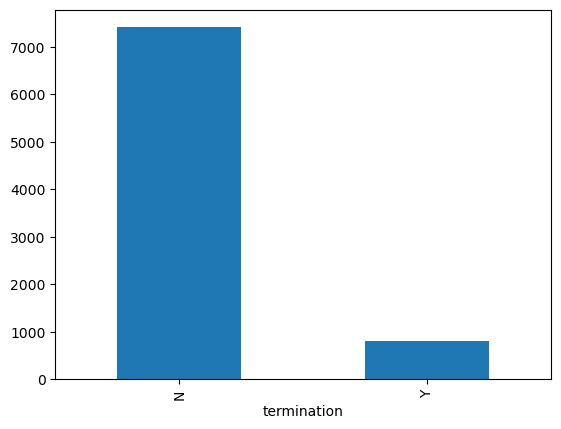

In [8]:
# termination 레이블 불균형 
df['termination'].value_counts().plot(kind='bar')

####
### **④ 데이터 전처리**

In [24]:
# 문자열 데이터 : class , sex, stop, npay, termination
df.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.0,0,N,N,2640.0000,792.00000,1584.0000,Y
1,E,F,24.0,1,N,N,16840.0000,2526.00000,6983.0000,N
2,F,F,32.0,1,N,N,15544.7334,2331.71001,6750.4666,N
3,D,M,18.0,1,N,N,4700.0000,0.00000,4502.0000,N
4,C,F,78.0,1,N,N,1361.7999,1173.99990,0.0000,N


##### <font color=blue> **[문제] replace 함수를 사용해서 'termination' 컬럼을 모델이 이해할수 있도록 Y --> 1 , N--> 0으로 변경하세요** </font>

In [32]:
# 대상 : df 데이터프레임 
# replace 함수 적용 대상 컬럼 : termination
# 방법1 :  replace( 'Y' , 1 ), replace( 'N' , 0 ) 각각 변경 적용
# 방법2 : df[ 'termination' ].replace( ['Y', 'N'] , [1, 0] ) 이렇게 한번에 적용





In [33]:
# termination 컬럼에 대해 replace 함수 적용후 확인
df.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.0,0,N,0,2640.0000,792.00000,1584.0000,1
1,E,F,24.0,1,N,0,16840.0000,2526.00000,6983.0000,0
2,F,F,32.0,1,N,0,15544.7334,2331.71001,6750.4666,0
3,D,M,18.0,1,N,0,4700.0000,0.00000,4502.0000,0
4,C,F,78.0,1,N,0,1361.7999,1173.99990,0.0000,0


In [25]:
# 라벨인코더 임포트
from sklearn.preprocessing import LabelEncoder

##### <font color=blue> **[문제] df DataFrame에서 'npay' 컬럼을 모델이 이해할수 있도록 라벨인코딩하세요.** </font>

In [27]:
# 대상 : df 데이터프레임 
# 라벨인코더 대상 컬럼 : npay
# LabelEncoder() 함수를 le 정의 및 fit_transform 적용





In [34]:
# npay 컬럼에 대해 라벨인코더 적용후 확인
df.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.0,0,N,0,2640.0000,792.00000,1584.0000,1
1,E,F,24.0,1,N,0,16840.0000,2526.00000,6983.0000,0
2,F,F,32.0,1,N,0,15544.7334,2331.71001,6750.4666,0
3,D,M,18.0,1,N,0,4700.0000,0.00000,4502.0000,0
4,C,F,78.0,1,N,0,1361.7999,1173.99990,0.0000,0


In [9]:
# 나머지 문자열 컬럼들 
cal_cols = ['class', 'sex', 'stop']

##### <font color=blue> **[문제] 나머지 Object 컬럼에 대해 Pandas get_dummies 함수 활용하여 원핫인코딩하세요.** </font>

In [35]:
# 대상 : df 데이터프레임 
# 원핫인코딩 대상 컬럼 : 'class', 'sex', 'stop'
# Pandas get_dummies 함수 활용
# get_dummies 함수의 옵션으로 가변수 제거하는 drop_first=True 설정





In [36]:
# 기존 1개의 class 컬럼이  5개의 class_D, class_E, class_F, class_G, class_H 컬럼으로 원핫인코딩 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8228 entries, 0 to 8227
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          8228 non-null   float64
 1   service      8228 non-null   int64  
 2   npay         8228 non-null   int32  
 3   avg_bill     8228 non-null   float64
 4   A_bill       8228 non-null   float64
 5   B_bill       8228 non-null   float64
 6   termination  8228 non-null   int64  
 7   class_D      8228 non-null   bool   
 8   class_E      8228 non-null   bool   
 9   class_F      8228 non-null   bool   
 10  class_G      8228 non-null   bool   
 11  class_H      8228 non-null   bool   
 12  sex_M        8228 non-null   bool   
 13  stop_Y       8228 non-null   bool   
dtypes: bool(7), float64(4), int32(1), int64(2)
memory usage: 474.2 KB


####
### **⑤ Train, Test  데이터셋 분할**

#### 입력(X)과 레이블(y) 나누기

##### <font color=blue> **[문제] df DataFrame에서 'termination' 컬럼을 제외한 나머지 정보를 X에 저장하세요.** </font>

In [37]:
# 대상 : df 데이터프레임 
# DataFrame drop 함수 활용
# 'termination' 컬럼 삭제
# DataFrame에서 values만 X에 저장





##### <font color=blue> **[문제] df DataFrame에서 'termination' 컬럼을 y로 저장하세요.** </font>

In [38]:
# 대상 : df 데이터프레임
# DataFrame 'termination' 컬럼 사용
# DataFrame에서 values만 y에 저장





In [14]:
X.shape, y.shape

((8228, 13), (8228,))

#### Train , Test dataset 나누기

In [39]:
from sklearn.model_selection import train_test_split

##### <font color=blue> **[문제] Train dataset, Test dataset 나누세요.** </font>

In [40]:
# Train dataset, Test dataset 나누기 : train_test_split 함수 사용
# 입력 : X, y 
# Train : Test 비율 = 7: 3  --> test_size=0.3
# y Class 비율에 맞게 나주어 주세요 : stratify=y
# 여러번 수행해도 같은 결과 나오게 고정하기 : random_state=42 
# 결과 : X_train, X_test, y_train, y_test






In [41]:
X_train.shape

(5759, 13)

In [42]:
y_train.shape

(5759,)

####
### **⑥ 데이터 정규화/스케일링(Normalizing/Scaling)**

In [43]:
# 숫자 분포 이루어진 컬럼 확인
df.tail()

,age,service,npay,avg_bill,A_bill,B_bill,termination,class_D,class_E,class_F,class_G,class_H,sex_M,stop_Y
8223,76.0,1,N,1860.0000,1716.000000,0.0000,N,False,False,False,False,False,True,False
8224,15.0,1,Y,1296.0999,194.414985,643.1001,N,False,False,False,False,False,False,False
8225,12.0,1,N,13799.6666,2069.949990,10605.9266,N,False,False,False,True,False,True,False
8226,40.0,0,N,3140.0000,942.000000,1884.0000,Y,False,False,False,False,False,False,False
8227,59.0,1,N,2436.9000,365.535000,1839.9000,N,False,False,False,False,False,False,False


In [44]:
from sklearn.preprocessing import MinMaxScaler

##### <font color=blue> **[문제] MinMaxScaler 함수를 'scaler'로 정의 하세요.** </font>

In [45]:
# 사이키런의 MinMaxScaler() 함수 활용
# 정의할 결과를 'scaler'로 매핑





In [46]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
# 출력된 값들이 0~1사이의 값들로 변한걸 확인
X_train[:2], y_train[:2]

(array([[0.60824742, 0.45454545, 0.        , 0.08540698, 0.01766813,
         0.1391709 , 0.        , 0.        , 1.        , 0.        ,
         0.        , 1.        , 0.        ],
        [0.48453608, 0.        , 0.        , 0.04043276, 0.01399892,
         0.05595675, 1.        , 0.        , 0.        , 0.        ,
         0.        , 1.        , 0.        ]]),
 array([0, 1], dtype=int64))

####
### **⑦ 모델 개발**

#### 모델별 바차트 그려주고 성능 확인을 위한 함수

In [48]:
# 모델별로 Accuracy 점수 저장
# 모델 Accuracy 점수 순서대로 바차트를 그려 모델별로 성능 확인 가능

from sklearn.metrics import accuracy_score

my_predictions = {}

colors = ['r', 'c', 'm', 'y', 'k', 'khaki', 'teal', 'orchid', 'sandybrown',
          'greenyellow', 'dodgerblue', 'deepskyblue', 'rosybrown', 'firebrick',
          'deeppink', 'crimson', 'salmon', 'darkred', 'olivedrab', 'olive', 
          'forestgreen', 'royalblue', 'indigo', 'navy', 'mediumpurple', 'chocolate',
          'gold', 'darkorange', 'seagreen', 'turquoise', 'steelblue', 'slategray', 
          'peru', 'midnightblue', 'slateblue', 'dimgray', 'cadetblue', 'tomato'
         ]

# 모델명, 예측값, 실제값을 주면 위의 plot_predictions 함수 호출하여 Scatter 그래프 그리며
# 모델별 MSE값을 Bar chart로 그려줌
def accuracy_eval(name_, pred, actual):
    global predictions
    global colors

    plt.figure(figsize=(12, 9))

    acc = accuracy_score(actual, pred)
    my_predictions[name_] = acc * 100

    y_value = sorted(my_predictions.items(), key=lambda x: x[1], reverse=True)
    
    df = pd.DataFrame(y_value, columns=['model', 'accuracy'])
    print(df)
   
    length = len(df)
    
    plt.figure(figsize=(10, length))
    ax = plt.subplot()
    ax.set_yticks(np.arange(len(df)))
    ax.set_yticklabels(df['model'], fontsize=15)
    bars = ax.barh(np.arange(len(df)), df['accuracy'])
    
    for i, v in enumerate(df['accuracy']):
        idx = np.random.choice(len(colors))
        bars[i].set_color(colors[idx])
        ax.text(v + 2, i, str(round(v, 3)), color='k', fontsize=15, fontweight='bold')
        
    plt.title('accuracy', fontsize=18)
    plt.xlim(0, 100)
    
    plt.show()

####  
### **1) 로지스틱 회귀 (LogisticRegression, 분류)**

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

##### <font color=blue> **[문제] LogisticRegression 모델 정의하고 학습시키세요.** </font>

In [50]:
# LogisticRegression 함수 사용 및 정의 : lg 저장
# 정의된 LogisticRegression 학습 fit() : 입력값으로 X_train, y_train 준다.




LogisticRegression()

In [51]:
# 분류기 성능 평가(score)
lg.score(X_test, y_test)

0.9194005670311867

- 분류기 성능 평가 지표

In [52]:
lg_pred = lg.predict(X_test)

In [53]:
# 오차행렬
# TN  FP
# FN  TP

confusion_matrix(y_test, lg_pred) 

array([[2219,    5],
       [ 194,   51]], dtype=int64)

In [54]:
# 정확도 : 굉장히 높다
accuracy_score(y_test, lg_pred)  

0.9194005670311867

In [55]:
# 정밀도
precision_score(y_test, lg_pred) 

0.9107142857142857

In [56]:
# 재현율 : 굉장히 낮다.
recall_score(y_test, lg_pred)  

0.20816326530612245

In [57]:
# 정밀도 + 재현율
f1_score(y_test, lg_pred) 

0.3388704318936877

In [58]:
print(classification_report(y_test, lg_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      2224
           1       0.91      0.21      0.34       245

    accuracy                           0.92      2469
   macro avg       0.92      0.60      0.65      2469
weighted avg       0.92      0.92      0.90      2469



                model   accuracy
0  LogisticRegression  91.940057


<Figure size 1200x900 with 0 Axes>

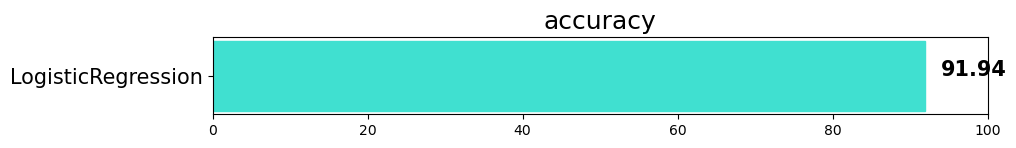

In [59]:
accuracy_eval('LogisticRegression', lg_pred, y_test)

####   
### **2) KNN (K-Nearest Neighbor)**

In [61]:
from sklearn.neighbors import KNeighborsClassifier

##### <font color=blue> **[문제] KNeighborsClassifier 모델 정의하고 학습시키세요.** </font>

In [62]:
# KNeighborsClassifier 함수 사용 및 정의 : knn 저장
# 정의된 KNeighborsClassifier 학습 fit() : 입력값으로 X_train, y_train 준다.




KNeighborsClassifier()

In [63]:
knn_pred = knn.predict(X_test)

                model   accuracy
0  K-Nearest Neighbor  95.909275
1  LogisticRegression  91.940057


<Figure size 1200x900 with 0 Axes>

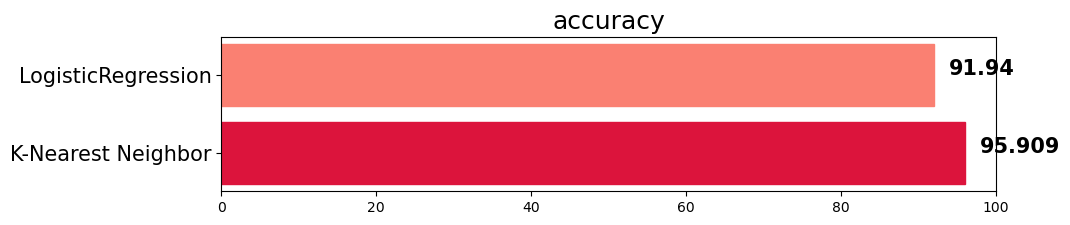

In [64]:
accuracy_eval('K-Nearest Neighbor', knn_pred, y_test)

####  
### **3) 결정트리(DecisionTree)**

In [65]:
from sklearn.tree import DecisionTreeClassifier

In [66]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

##### <font color=blue> **[문제] 학습된 DecisionTreeClassifier 모델로 예측해 보기** </font>

In [67]:
# DecisionTreeClassifier 학습 모델 : dt
# DecisionTreeClassifier 모델의 predict() 활용 : 입력값으로 X_test
# 결과 : dt_pred 저장





                model   accuracy
0        DecisionTree  97.934386
1  K-Nearest Neighbor  95.909275
2  LogisticRegression  91.940057


<Figure size 1200x900 with 0 Axes>

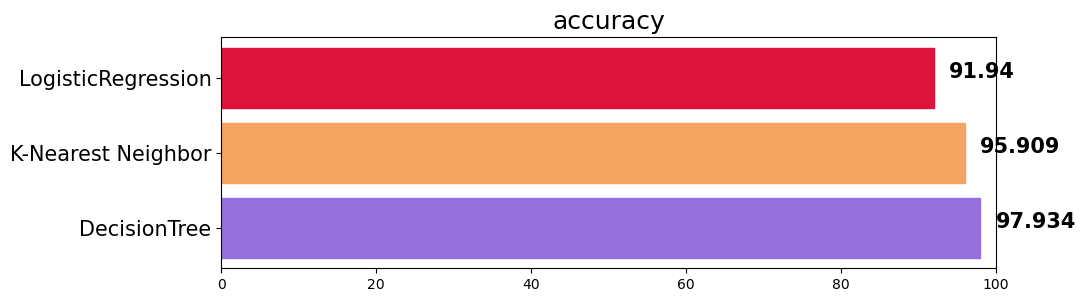

In [68]:
accuracy_eval('DecisionTree', dt_pred, y_test)

### 
### **앙상블 기법의 종류**
- 배깅 (Bagging): 여러개의 DecisionTree 활용하고 샘플 중복 생성을 통해 결과 도출. RandomForest
- 부스팅 (Boosting): 약한 학습기를 순차적으로 학습을 하되, 이전 학습에 대하여 잘못 예측된 데이터에 가중치를 부여해 오차를 보완해 나가는 방식. XGBoost, LGBM
- 스태킹 (Stacking): 여러 모델을 기반으로 예측된 결과를 통해 Final 학습기(meta 모델)이 다시 한번 예측

![앙상블](https://teddylee777.github.io/images/2019-12-18/image-20191217144823555.png)

####  
### **4) 랜덤포레스트(RandomForest)**
+ Bagging 대표적인 모델로써, 훈련셋트를 무작위로 각기 다른 서브셋으로 데이터셋을 만들고
+ 여러개의 DecisonTree로 학습하고 다수결로 결정하는 모델

**주요 Hyperparameter**
- random_state: 랜덤 시드 고정 값. 고정해두고 튜닝할 것!
- n_jobs: CPU 사용 갯수
- max_depth: 깊어질 수 있는 최대 깊이. 과대적합 방지용
- n_estimators: 앙상블하는 트리의 갯수
- max_features: 최대로 사용할 feature의 갯수. 과대적합 방지용
- min_samples_split: 트리가 분할할 때 최소 샘플의 갯수. default=2. 과대적합 방지용

In [69]:
from sklearn.ensemble import RandomForestClassifier

##### <font color=blue> **[문제] RandomForestClassifier 모델 정의하고 학습시키세요.** </font>

In [70]:
# RandomForestClassifier 함수 사용 및 정의 : rfc 저장
# RandomForestClassifier 함수 정의시 n_estimators=3, random_state=42 하이퍼라파미터 설정하기
# 정의된 RandomForestClassifier 학습 fit() : 입력값으로 X_train, y_train 준다.





RandomForestClassifier(n_estimators=3, random_state=42)

In [71]:
rfc_pred = rfc.predict(X_test)

                   model   accuracy
0           DecisionTree  97.934386
1  RandomForest Ensemble  97.812880
2     K-Nearest Neighbor  95.909275
3     LogisticRegression  91.940057


<Figure size 1200x900 with 0 Axes>

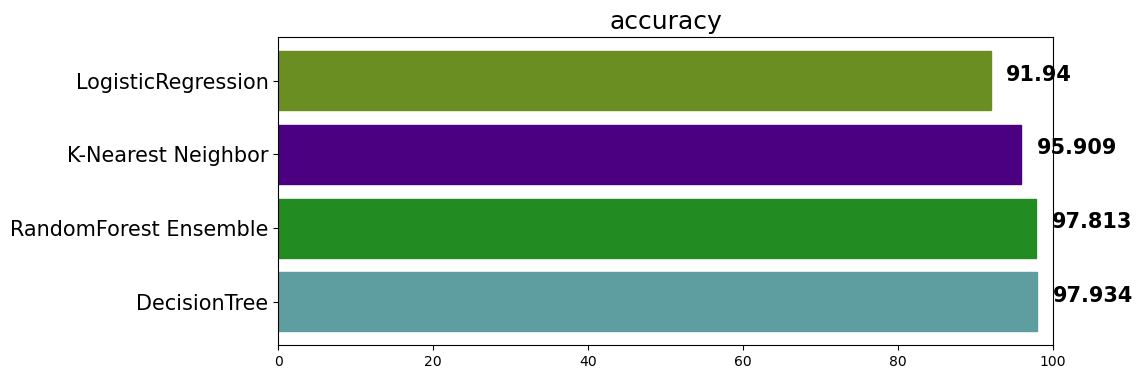

In [72]:
accuracy_eval('RandomForest Ensemble', rfc_pred, y_test)

####  
### **5) XGBoost**
+ 여러개의 DecisionTree를 결합하여 Strong Learner 만드는 Boosting 앙상블 기법
+ Kaggle 대회에서 자주 사용하는 모델이다.

**주요 특징**
- scikit-learn 패키지가 아닙니다.
- 성능이 우수함
- GBM보다는 빠르고 성능도 향상되었습니다.
- 여전히 학습시간이 매우 느리다

**주요 Hyperparameter**
- random_state: 랜덤 시드 고정 값. 고정해두고 튜닝할 것!
- n_jobs: CPU 사용 갯수
- learning_rate: 학습율. 너무 큰 학습율은 성능을 떨어뜨리고, 너무 작은 학습율은 학습이 느리다. 적절한 값을 찾아야함. n_estimators와 같이 튜닝. default=0.1
- n_estimators: 부스팅 스테이지 수. (랜덤포레스트 트리의 갯수 설정과 비슷한 개념). default=100
- max_depth: 트리의 깊이. 과대적합 방지용. default=3. 
- subsample: 샘플 사용 비율. 과대적합 방지용. default=1.0
- max_features: 최대로 사용할 feature의 비율. 과대적합 방지용. default=1.0

In [73]:
!pip install xgboost

Could not fetch URL https://pypi.org/simple/pip/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/pip/ (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1006)'))) - skipping


In [74]:
from xgboost import XGBClassifier

In [75]:
xgb = XGBClassifier(n_estimators=3, random_state=42)  
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=3, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [76]:
xgb_pred = xgb.predict(X_test)

                   model   accuracy
0                XGBoost  98.015391
1           DecisionTree  97.934386
2  RandomForest Ensemble  97.812880
3     K-Nearest Neighbor  95.909275
4     LogisticRegression  91.940057


<Figure size 1200x900 with 0 Axes>

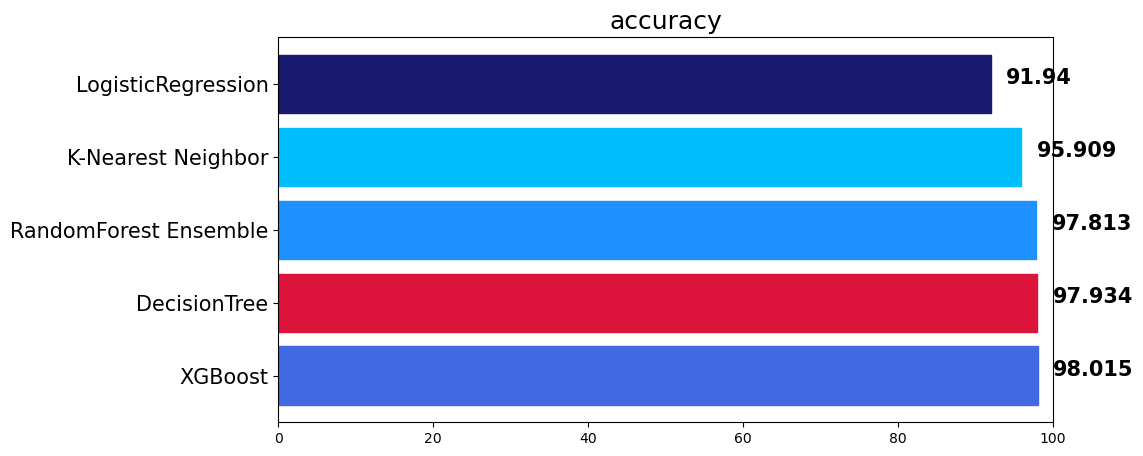

In [77]:
accuracy_eval('XGBoost', xgb_pred, y_test)

# 
# **배운 내용 정리**
1. 머신러닝 모델 프로세스 <br>
① 라이브러리 임포트(import)  
② 데이터 가져오기(Loading the data)  
③ 탐색적 데이터 분석(Exploratory Data Analysis)  
④ 데이터 전처리(Data PreProcessing) : 데이터타입 변환, Null 데이터 처리, 누락데이터 처리, 
더미특성 생성, 특성 추출 (feature engineering) 등  
⑤ Train, Test  데이터셋 분할  
⑥ 데이터 정규화(Normalizing the Data)  
⑦ 모델 개발(Creating the Model)  
⑧ 모델 성능 평가
2. 평가 지표 활용 : 모델별 성능 확인을 위한 함수 (가져다 쓰면 된다)
3. 단일 회귀예측 모델 : LogisticRegression, KNN, DecisionTree
4. 앙상블 (Ensemble) : RandomForest, XGBoost